In [3]:
import os

# Diretório onde queremos salvar todos os arquivos gerados
proxy_dir_win = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Codes_Optimization_Reservoir\codes_Proxy"
proxy_dir_wsl = "/mnt/" + proxy_dir_win[0].lower() + proxy_dir_win[2:].replace("\\","/")

# Diretório do mapa base (original oficial do modelo Egg)
base_map_win = r"C:\Users\calva\OneDrive\Documentos\Doutorado\benchmark\OPM_Egg_originais"
base_map_wsl = "/mnt/" + base_map_win[0].lower() + base_map_win[2:].replace("\\","/")

# Diretórios dos períodos
period1_win = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Codes_Optimization_Reservoir\Egg - Two"
period2_win = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Codes_Optimization_Reservoir\Egg - Four"

period1_wsl = "/mnt/" + period1_win[0].lower() + period1_win[2:].replace("\\","/")
period2_wsl = "/mnt/" + period2_win[0].lower() + period2_win[2:].replace("\\","/")

# Caminho final do arquivo .npy do mapa base
layer_map_win = os.path.join(proxy_dir_win, "layer0_base.npy")
layer_map_wsl = "/mnt/" + layer_map_win[0].lower() + layer_map_win[2:].replace("\\","/")

In [4]:
script_win = os.path.join(proxy_dir_win, "extract_layer0.py")
script_wsl = "/mnt/" + script_win[0].lower() + script_win[2:].replace("\\","/")

script_content = r'''
import numpy as np
from ecl.grid import EclGrid
from ecl.eclfile import EclFile
import os, sys

model_path = sys.argv[1]
output_npy = sys.argv[2]

# Arquivos corretos do modelo base Egg
egrid = os.path.join(model_path, "EGG_MODEL_ECL.EGRID")
initf = os.path.join(model_path, "EGG_MODEL_ECL.INIT")

grid = EclGrid(egrid)
nx, ny, nz = grid.getNX(), grid.getNY(), grid.getNZ()
actnum = np.array(grid.export_actnum(), dtype=bool)

init = EclFile(initf)
permx = init["PERMX"][0]

perm3d = np.full((nx * ny * nz,), np.nan)
perm3d[actnum] = permx
perm3d = perm3d.reshape((nx, ny, nz), order="F")

layer0 = perm3d[:,:,0]
np.save(output_npy, layer0)
'''

with open(script_win, "w") as f:
    f.write(script_content)

print("✔ Script criado em:", script_win)

✔ Script criado em: C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Codes_Optimization_Reservoir\codes_Proxy\extract_layer0.py


In [5]:
import subprocess

cmd = f'python3 "{script_wsl}" "{base_map_wsl}" "{layer_map_wsl}"'
print("Rodando:", cmd)

res = subprocess.run(["wsl", "bash", "-c", cmd], text=True, capture_output=True)

print("STDOUT:", res.stdout)
print("STDERR:", res.stderr)
print("Return code:", res.returncode)

Rodando: python3 "/mnt/c/Users/calva/OneDrive/Documentos/Doutorado/Proposta_de_Tese/Codes_Optimization_Reservoir/codes_Proxy/extract_layer0.py" "/mnt/c/Users/calva/OneDrive/Documentos/Doutorado/benchmark/OPM_Egg_originais" "/mnt/c/Users/calva/OneDrive/Documentos/Doutorado/Proposta_de_Tese/Codes_Optimization_Reservoir/codes_Proxy/layer0_base.npy"
STDOUT: 
STDERR: 
Return code: 0


In [6]:
def extract_well_coords(data_file):
    wells = []
    inside = False

    with open(data_file, "r") as f:
        for line in f:
            if "WELSPECS" in line:
                inside = True
                continue
            if inside:
                if line.strip().startswith("/"):
                    break
                parts = line.split()
                name = parts[0]
                i = int(parts[2])
                j = int(parts[3])
                wells.append((name, i, j))
    return wells

In [7]:
def fix_well_names_period2(wells):
    """
    Ajusta os nomes dos poços do período 2.
    Os dois primeiros devem ser PROD1 e INJECT1,
    e os dois seguintes PROD2 e INJECT2.
    """
    corrected = []

    mapping = ["PROD1", "INJECT1", "PROD2", "INJECT2"]

    for idx, (name, i, j) in enumerate(wells):
        if idx < len(mapping):
            corrected_name = mapping[idx]
        else:
            corrected_name = name  # mantém nomes extras caso existam
        corrected.append((corrected_name, i, j))

    return corrected

In [8]:
period1_data = os.path.join(period1_win, "EGG.DATA")
period2_data = os.path.join(period2_win, "EGG.DATA")

wells_p1 = extract_well_coords(period1_data)
wells_p2_raw = extract_well_coords(period2_data)

wells_p2 = fix_well_names_period2(wells_p2_raw)

print("Período 1:", wells_p1)
print("Período 2:", wells_p2)

Período 1: [('PROD1', 16, 43), ('INJECT1', 5, 57)]
Período 2: [('PROD1', 16, 43), ('INJECT1', 5, 57), ('PROD2', 37, 24), ('INJECT2', 17, 41)]


In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_two_maps_side_by_side(layer, wells1, wells2):
    vmin, vmax = 2, 3.6  # Limites da escala log10
    logp = np.log10(np.where(layer > 0, layer, np.nan))

    fig, axes = plt.subplots(
        1, 2, figsize=(10, 5),
        sharex=True, sharey=True,
        constrained_layout=True   # <-- substitui tight_layout()
    )

    # --- Período 1 ---
    ax = axes[0]
    img = ax.imshow(logp.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
    for name, x, y in wells1:
        color = "black" if "PROD" in name.upper() else "b"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period I", fontsize=14)
    ax.set_xlabel("X direction")
    ax.set_ylabel("Y direction")

    # --- Período 2 ---
    ax = axes[1]
    ax.imshow(logp.T, cmap="jet", origin="lower")
    for name, x, y in wells2:
        color = "black" if "PROD" in name.upper() else "b"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period II", fontsize=14)
    ax.set_xlabel("X direction")

    # --- Colorbar única ---
    fig.colorbar(img, ax=axes, shrink=0.8, label="log10(permeability)")

    plt.show()

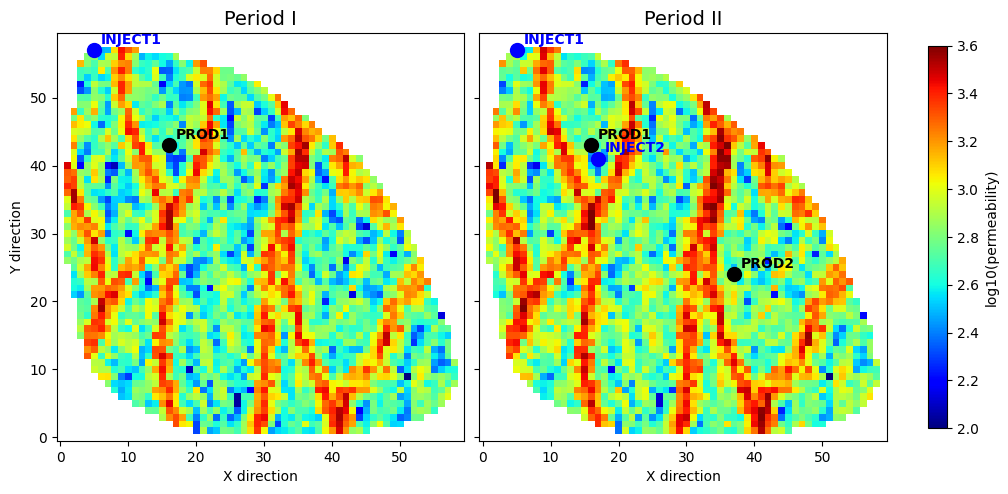

In [26]:
layer0 = np.load(layer_map_win)
plot_two_maps_side_by_side(layer0, wells_p1, wells_p2)

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_two_maps_side_by_side(layer, wells1, wells2):

    vmin, vmax = 2, 3.6  # Limites da escala log10
    logp = np.log10(np.where(layer > 0, layer, np.nan))

    fig, axes = plt.subplots(
        1, 2, figsize=(10, 5),
        sharex=True, sharey=True,
        constrained_layout=True
    )

    # --- Período 1 ---
    ax = axes[0]
    img = ax.imshow(logp.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
    for name, x, y in wells1:
        color = "black" if "PROD" in name.upper() else "r"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period I", fontsize=14)
    ax.set_xlabel("X direction")
    ax.set_ylabel("Y direction")

    # --- Período 2 ---
    ax = axes[1]
    ax.imshow(logp.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
    for name, x, y in wells2:
        color = "black" if "PROD" in name.upper() else "r"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period II", fontsize=14)
    ax.set_xlabel("X direction")

    # --- Colorbar única ---
    fig.colorbar(img, ax=axes, shrink=0.8, label="log10(permeability)")

    # --- Caminho para salvar ---
    save_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Deep_Learning\artigo\MDPI_template_ACS\Definitions\map_periods.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print(f"Figura salva em:\n{save_path}")

    plt.show()

Figura salva em:
C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Deep_Learning\artigo\MDPI_template_ACS\Definitions\map_periods.png


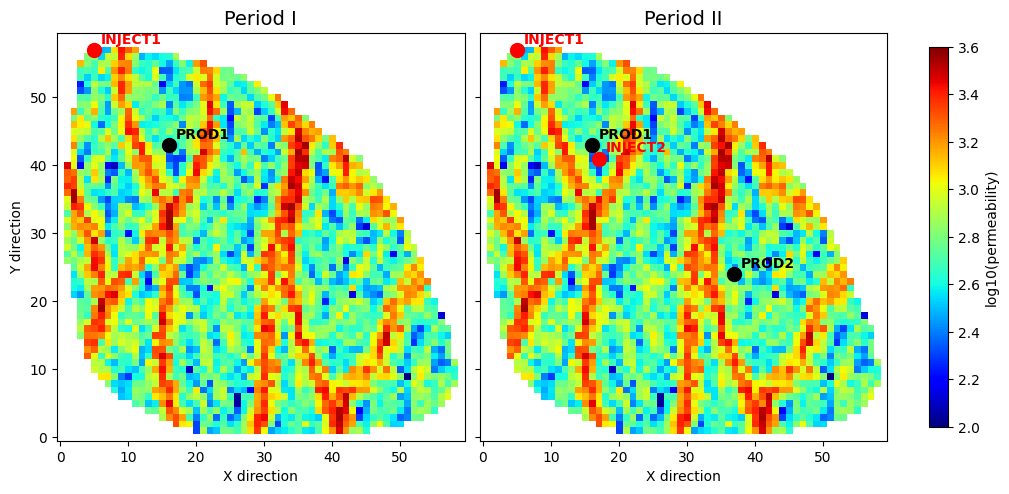

In [40]:
layer0 = np.load(layer_map_win)
plot_two_maps_side_by_side(layer0, wells_p1, wells_p2)

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_two_maps_side_by_side(layer, wells1, wells2):

    vmin, vmax = 2, 3.6  # Limites da escala log10
    logp = np.log10(np.where(layer > 0, layer, np.nan))

    fig, axes = plt.subplots(
        1, 2, figsize=(10, 5),
        sharex=True, sharey=True,
        constrained_layout=True
    )

    # --- Função auxiliar para remover completamente os eixos ---
    def remove_axes(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)

    # --- Período 1 ---
    ax = axes[0]
    img = ax.imshow(logp.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
    for name, x, y in wells1:
        color = "black" if "PROD" in name.upper() else "k"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period I", fontsize=14)
    remove_axes(ax)

    # --- Período 2 ---
    ax = axes[1]
    ax.imshow(logp.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
    for name, x, y in wells2:
        color = "black" if "PROD" in name.upper() else "k"
        ax.plot(x, y, "o", markersize=10, color=color)
        ax.text(x+1, y+1, name, fontsize=10, weight="bold", color=color)
    ax.set_title("Period II", fontsize=14)
    remove_axes(ax)

    # --- Colorbar ---
    #fig.colorbar(img, ax=axes, shrink=0.8, label="log10(permeability)")

    # --- Caminho para salvar ---
    save_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Deep_Learning\artigo\MDPI_template_ACS\Definitions\map_periods.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print(f"Figura salva em:\n{save_path}")

    plt.show()

Figura salva em:
C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Deep_Learning\artigo\MDPI_template_ACS\Definitions\map_periods.png


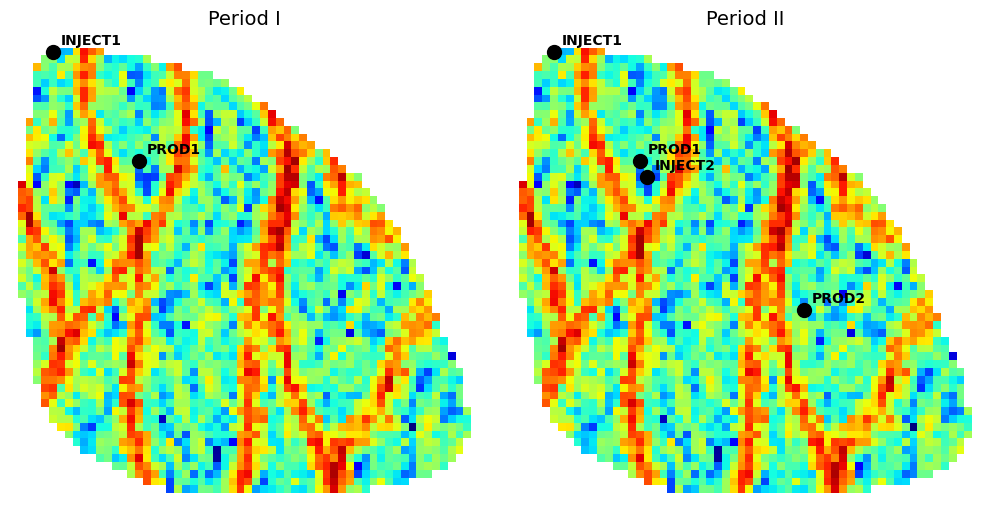

In [46]:
layer0 = np.load(layer_map_win)
plot_two_maps_side_by_side(layer0, wells_p1, wells_p2)

# Primeiro periodo

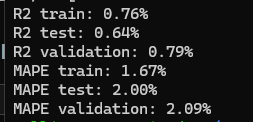

# Segundo periodo

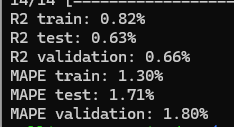